# Investigate the difference of the sequence measurements based on their cell-type
### Outline: 
1. Upset plot of the sequence measurement groups within the cell-type (more active vs scrambled; no activity difference vs scrambled; less active vs scrambled) 
2. Define the baseline set as sequences within both cell-types that are not active + how many sequences are in this group
3. Sequence based differences between the sequence based groups: use the enrichment analysis Pia showed you and the sequence set from 2


In [1]:
import pandas as pd
import yaml

config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

# load helpful functions
import sys
sys.path.append('../00_helpful_functions')
import helpful_functions as hf

In [2]:
# read the file
df_elements = pd.read_csv(config['files']['creating']['element_info_ngn2_undiffwtc11_202506'], sep='\t')
df_elements

,name,chr,start,end,strand,sequence,label,raw_activity_NGN2_log2FC_bcalm,bcalm_adj_p_NGN2,normalized_activity_NGN2,...,SCREEN_ID,is_NPC_SCREEN_cCRE,is_WTC11_SCREEN_cCRE,is_H9_SCREEN_cCRE,is_H1_SCREEN_cCRE,is_dCRE_NGN2,is_dCRE_undiffWTC11,bcalm_effect_NGN2,bcalm_effect_undiffWTC11,measured_in_both_celltypes
0,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70276484.0,70276754.0,-,CTTGAATTTGAATTTAGAGTGAACATGTTGTGATTTTGTATCTGTG...,tested,-0.089726,2.492488e-03,-1.928542,...,EH38E1825144,False,False,False,False,True,False,decreasing,no_effect,True
1,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70323127.0,70323397.0,-,GCAGTGGCTCATGCCTGCAATCTCAGCACTTCGGGAGGTTGAGGTG...,tested,-0.026591,1.000000e+00,-0.295843,...,EH38E1825170,False,False,False,False,False,False,no_effect,no_effect,True
2,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70325057.0,70325327.0,-,GCAAGGATCTAAAGTTCCAATTGGCATTAGCTTTCTTTTCGTTTAC...,tested,-0.033114,1.000000e+00,-0.464529,...,EH38E1825171,False,False,False,False,False,False,no_effect,no_effect,True
3,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70213614.0,70213884.0,-,TTTTTTCAGGAAGTGAAGAATTTAGAGGGATAAAAGGCGGAAATAA...,tested,-0.018290,1.000000e+00,-0.081174,...,EH38E3188739,False,False,False,False,False,False,no_effect,no_effect,True
4,cardiac_neuro_cava_random:AARS1|ENSG0000009086...,chr16,70277149.0,70277419.0,-,ATCTGGCAGGCCTTTCCCCTCTGCAGGTGGTGTCACTCGTGGTGGT...,tested,-0.038026,1.000000e+00,-0.591552,...,EH38E3188758,False,False,False,False,False,False,no_effect,no_effect,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73935,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,106984308.0,106984578.0,+,TAGAAAAGCACAATGAACTGAAACCTTACAAATGCCAGCTCTGCTA...,tested,-0.076844,1.000000e+00,-1.595406,...,EH38E3899597,False,False,False,False,False,False,no_effect,no_effect,True
73936,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107008116.0,107008386.0,+,AAGCAGAATCCTCCCCACCCCCCTCTCATTATGCAGTTGGGGAGGA...,tested,0.138223,8.599369e-22,3.966275,...,EH38E3899600,False,False,False,False,True,False,increasing,no_effect,True
73937,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107019262.0,107019532.0,+,GAAGAGGTCCCCTGGGTCTGAAAATTATAATAGACGGCAGCAGTGA...,tested,0.054619,3.581264e-01,1.804262,...,EH38E3899604,False,False,False,False,False,False,no_effect,no_effect,True
73938,cardiac_neuro_cava_random:ZNF462|ENSG000001481...,chr9,107038939.0,107039209.0,+,CTGTCTTCAAGCATCCTAAATCTTTTATATGAGTGTCTCTAGAAGG...,tested,-0.064615,1.000000e+00,-1.279153,...,EH38E3899614,False,False,False,False,False,False,no_effect,no_effect,True


### Classify the elements based on the bcalm results and identify the elements which are not active in both cell types as background set
- Number of oligos measured in both cell-types: 67,451

IDEA: We would like to investigate the sequence based differences of sequences which were measured with high activity in one cell-type but are not active in the other cell-type. What is the difference? 
There are three groups of sequences 

In [ ]:
df_elements_both_cell_types = df_elements.loc[df_elements['measured_in_both_celltypes']].copy()
df_elements_both_cell_types

# filter out all alt alleles
df_elements_both_cell_types_no_alt = df_elements_both_cell_types.loc[~df_elements_both_cell_types['name'].str.startswith("cardiac_neuro_cava_random:ALT_")].copy()

# how many different regions are in both cell-types (defined by chr, start, end, strand)
df_elements_both_cell_types_no_alt['region'] = df_elements_both_cell_types_no_alt.apply(
    lambda x: f"{x['chr']}_{x['start']}_{x['end']}_{x['strand']}", axis=1)
print("Number of different regions defined by chr, start, end, strand with measurments in both cell types (without alt alleles):")
df_elements_both_cell_types_no_alt['region'].nunique() # with alt: 26022; without alt: 25304

25304

In [16]:
if df_elements_both_cell_types_no_alt['region'].duplicated().sum() > 0:
    print("There are duplicate regions in the dataset.")
else:
    print("No duplicate regions found.")

No duplicate regions found.


In [18]:
df_elements_both_cell_types_no_alt.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'region'],
      dtype='object')

In [ ]:
df_elements_both_cell_types_no_alt['bcalm_effect_NGN2'].value_counts()

bcalm_effect_NGN2
no_effect     23956
increasing      765
decreasing      583
Name: count, dtype: int64

In [20]:
df_elements_both_cell_types_no_alt['bcalm_effect_undiffWTC11'].value_counts()

bcalm_effect_undiffWTC11
no_effect     25175
increasing      113
decreasing       16
Name: count, dtype: int64

### Generate upset plot of the sequence measurement groups within the cell-type

In [ ]:
import matplotlib.pyplot as plt
from upsetplot import plot, from_memberships


/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/kisa/miniforge3/envs/mobil/lib/python3.9/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting valu

<Figure size 1000x600 with 0 Axes>

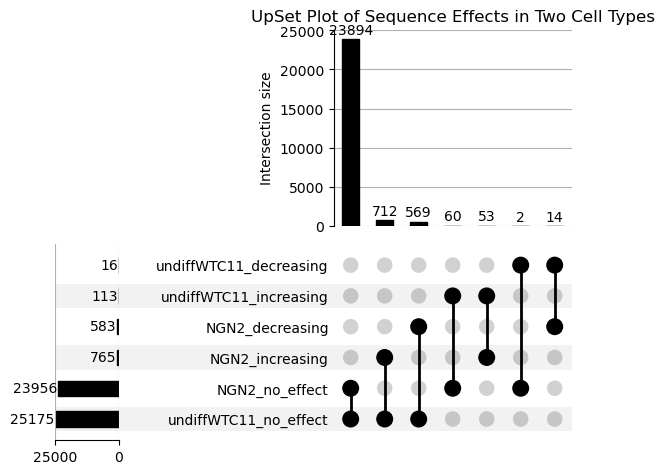

In [27]:
from upsetplot import UpSet, from_indicators
# Create binary indicator columns
categories = ['increasing', 'decreasing', 'no_effect']
for cat in categories:
    df_elements_both_cell_types_no_alt[f'NGN2_{cat}'] = df_elements_both_cell_types_no_alt['bcalm_effect_NGN2'] == cat
    df_elements_both_cell_types_no_alt[f'undiffWTC11_{cat}'] = df_elements_both_cell_types_no_alt['bcalm_effect_undiffWTC11'] == cat

# List of new boolean columns
indicator_cols = [f'NGN2_{c}' for c in categories] + [f'undiffWTC11_{c}' for c in categories]

# Prepare the data for upsetplot
upset_data = from_indicators(indicator_cols, df_elements_both_cell_types_no_alt)

# Plot
plt.figure(figsize=(10, 6))
UpSet(upset_data, show_counts=True, sort_by='degree').plot()
plt.title("UpSet Plot of Sequence Effects in Two Cell Types")
plt.show()

Numbers: undiffWTC11: decreasing set 16: 14 decreasing in NGN2 and 2 no effect in NGN2; increasing set 113: 53 with increasing in NGN2 and 60 no effect in NGN2; No effect undiffWTC11 (25175) 23894 are within no effect NGN2 and 712 are overlapping with increasing in NGN2 and 569 with decreasing in NGN2
NGN2: decreasing set 583: 14 decreasing in undiffWTC11 and 569 no effect in undiffWTC11; increasing set 765: 712 overlapp with no effect in undiffWTC11 and 53 with decreasing in undiffWTC11; 
Interpretation: The overlap between the two cell types suggests that while there are distinct sets of elements affected by each condition, a significant number of elements exhibit similar behaviors across both cell types. This could indicate shared regulatory mechanisms or common pathways influencing the observed effects. The lower number of elements within the set of the undiffWTC11 cell type reduces the statistical power of the analysis, making it more challenging to draw robust conclusions about the differences between the two cell types. The number of sequences with decreasing effect is lower compared to increasing effects in both cell-types and the relative overlap of sequences with decreasing activity is higher compared to the increasing activity, which suggests that sequence patterns which are responsible for decreasing activity are more pronounced and shared between the two cell types.

### Plot the activity distribution of the "no significant effect within both cell-types" sequences

In [29]:
df_elements_both_cell_types_no_alt_no_effect = df_elements_both_cell_types_no_alt.loc[df_elements_both_cell_types_no_alt['NGN2_no_effect'] & df_elements_both_cell_types_no_alt['undiffWTC11_no_effect']]

In [31]:
df_elements_both_cell_types_no_alt_no_effect.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'region', 'NGN2_increasing',
       'undiffWTC11_increasing', 'NGN2_decreasing', 'undiffWTC11_decreasing',
       'NGN2_no_effect', 'undiffWTC11_no_effect'],
      dtype='object')

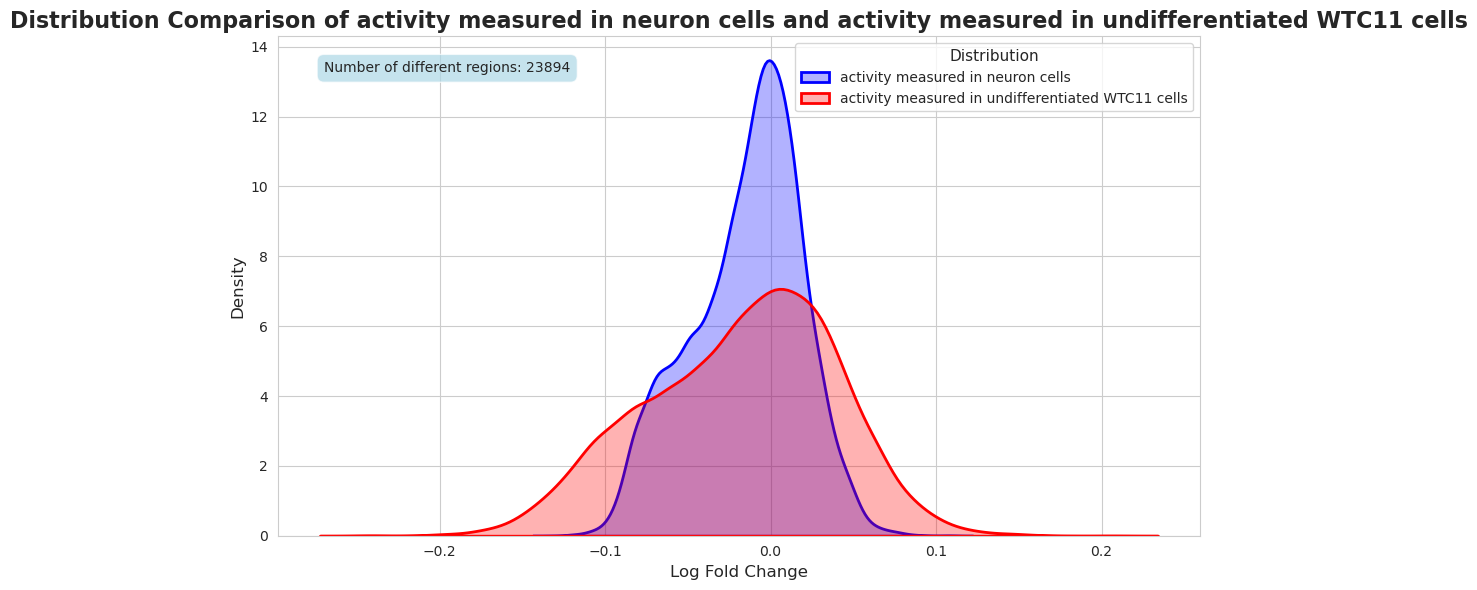

In [37]:


# plot two distributions using raw_activity_NGN2_log2FC_bcalm; and raw_activity_undiffWTC11_log2FC_bcalm respectively
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

column_one = 'raw_activity_NGN2_log2FC_bcalm'
column_name_one = 'activity measured in neuron cells'
column_two = 'raw_activity_undiffWTC11_log2FC_bcalm'
column_name_two = 'activity measured in undifferentiated WTC11 cells'

# --- 2. Calculate Statistics ---
# Calculate the median and standard deviation for each column.
median_new = df_elements_both_cell_types_no_alt_no_effect[f'{column_one}'].median()
std_new = df_elements_both_cell_types_no_alt_no_effect[f'{column_one}'].std()

median_world = df_elements_both_cell_types_no_alt_no_effect[f'{column_two}'].median()
std_world = df_elements_both_cell_types_no_alt_no_effect[f'{column_two}'].std()

# --- 3. Set Up Plot for Publication Readiness ---
plt.figure(figsize=(10, 6)) # Set figure size for better readability
sns.set_style("whitegrid") # Use a clean seaborn style for aesthetics

# --- 4. Plot the Distributions ---
# Use seaborn's kdeplot to visualize the distributions.
# 'fill=True' and 'alpha' add a shaded area for better visual comparison.
sns.kdeplot(df_elements_both_cell_types_no_alt_no_effect[f'{column_one}'], color='blue', label=f'{column_name_one}', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(df_elements_both_cell_types_no_alt_no_effect[f'{column_two}'], color='red', label=f'{column_name_two}', fill=True, alpha=0.3, linewidth=2)

# --- 5. Add Plot Elements (Title, Labels, Legend) ---
plt.title(f'Distribution Comparison of {column_name_one} and {column_name_two}', fontsize=16, fontweight='bold')
plt.xlabel('Log Fold Change', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Distribution', fontsize=10, title_fontsize='11', loc='upper right')

# Change the lable names of the compared distributions


# --- 6. Add Text Annotations for Statistics ---
# Format the statistics neatly in a text box.
# stats_text = (
#     f'raw_activity_NGN2_log2FC_bcalm:\n'
#     f'  Median = {median_new:.2f}\n'
#     f'  Std Dev = {std_new:.2f}\n\n'
#     f'raw_activity_undiffWTC11_log2FC_bcalm:\n'
#     f'  Median = {median_world:.2f}\n'
#     f'  Std Dev = {std_world:.2f}'
# )
# plt.text(0.70, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10,
        #  verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='lightyellow', alpha=0.7))

# --- 7. Add Text Annotation for Number of Rows ---
plt.text(0.05, 0.95, f'Number of different regions: {len(df_elements_both_cell_types_no_alt_no_effect)}', transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))

# --- 8. Final Touches and Saving ---
plt.tight_layout() # Adjust layout to prevent labels from overlapping
# plt.savefig('distribution_comparison_plot.png', dpi=300) # Save the plot as a high-resolution PNG
plt.show() # Display the plot



##### Take the normalized activity

In [38]:
df_elements_both_cell_types_no_alt_no_effect.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'region', 'NGN2_increasing',
       'undiffWTC11_increasing', 'NGN2_decreasing', 'undiffWTC11_decreasing',
       'NGN2_no_effect', 'undiffWTC11_no_effect'],
      dtype='object')

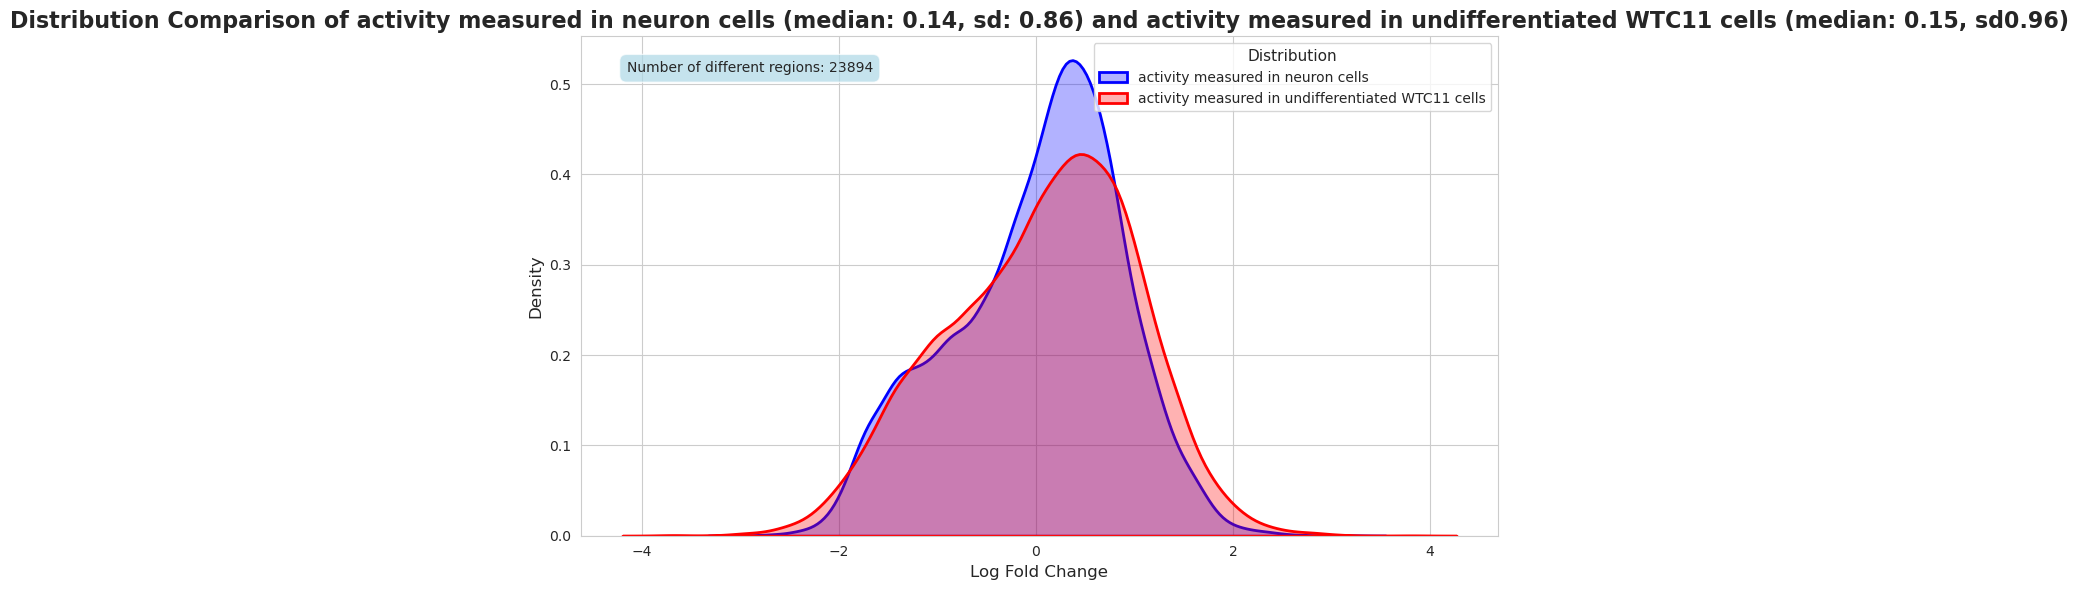

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

column_one = 'normalized_activity_NGN2'
column_name_one = 'activity measured in neuron cells'
column_two = 'normalized_activity_undiffWTC11'
column_name_two = 'activity measured in undifferentiated WTC11 cells'

# Calculate Statistics
# Calculate the median and standard deviation for each column.
median_first = df_elements_both_cell_types_no_alt_no_effect[f'{column_one}'].median()
std_first = df_elements_both_cell_types_no_alt_no_effect[f'{column_one}'].std()

median_second = df_elements_both_cell_types_no_alt_no_effect[f'{column_two}'].median()
std_second = df_elements_both_cell_types_no_alt_no_effect[f'{column_two}'].std()

# Set Up Plot for Publication Readiness
plt.figure(figsize=(10, 6)) # Set figure size for better readability
sns.set_style("whitegrid") # Use a clean seaborn style for aesthetics

# Plot the Distributions
# Use seaborn's kdeplot to visualize the distributions.
# 'fill=True' and 'alpha' add a shaded area for better visual comparison.
sns.kdeplot(df_elements_both_cell_types_no_alt_no_effect[f'{column_one}'], color='blue', label=f'{column_name_one}', fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(df_elements_both_cell_types_no_alt_no_effect[f'{column_two}'], color='red', label=f'{column_name_two}', fill=True, alpha=0.3, linewidth=2)

# Add Plot Elements (Title, Labels, Legend)
plt.title(f'Distribution Comparison of {column_name_one} (median: {median_first:.2f}, sd: {std_first:.2f}) and {column_name_two} (median: {median_second:.2f}, sd: {std_second:.2f})', fontsize=16, fontweight='bold')
plt.xlabel('Log Fold Change', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(title='Distribution', fontsize=10, title_fontsize='11', loc='upper right')

# Add Text Annotation for Number of Rows
plt.text(0.05, 0.95, f'Number of different regions: {len(df_elements_both_cell_types_no_alt_no_effect)}', transform=plt.gca().transAxes, fontsize=10,
         verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))

# Final Touches and Saving
plt.tight_layout() # Adjust layout to prevent labels from overlapping
# plt.savefig('distribution_comparison_plot.png', dpi=300) # Save the plot as a high-resolution PNG
plt.show() # Display the plot



#### Plot the activity distributions of many group combinations: 
- no activity in both cell-types (first)
- no activity neuron vs increasing activity in undiffWTC11
- no activity neuron vs decreasing activity in undiffWTC11
- increasing activity neuron vs no activity in undiffWTC11
- increasing activity neuron vs increasing activity in undiffWTC11
- increasing activity neuron vs decreasing activity in undiffWTC11
- decreasing activity neuron vs no activity in undiffWTC11
- decreasing activity neuron vs increasing activity in undiffWTC11
- decreasing activity neuron vs decreasing activity in undiffWTC11

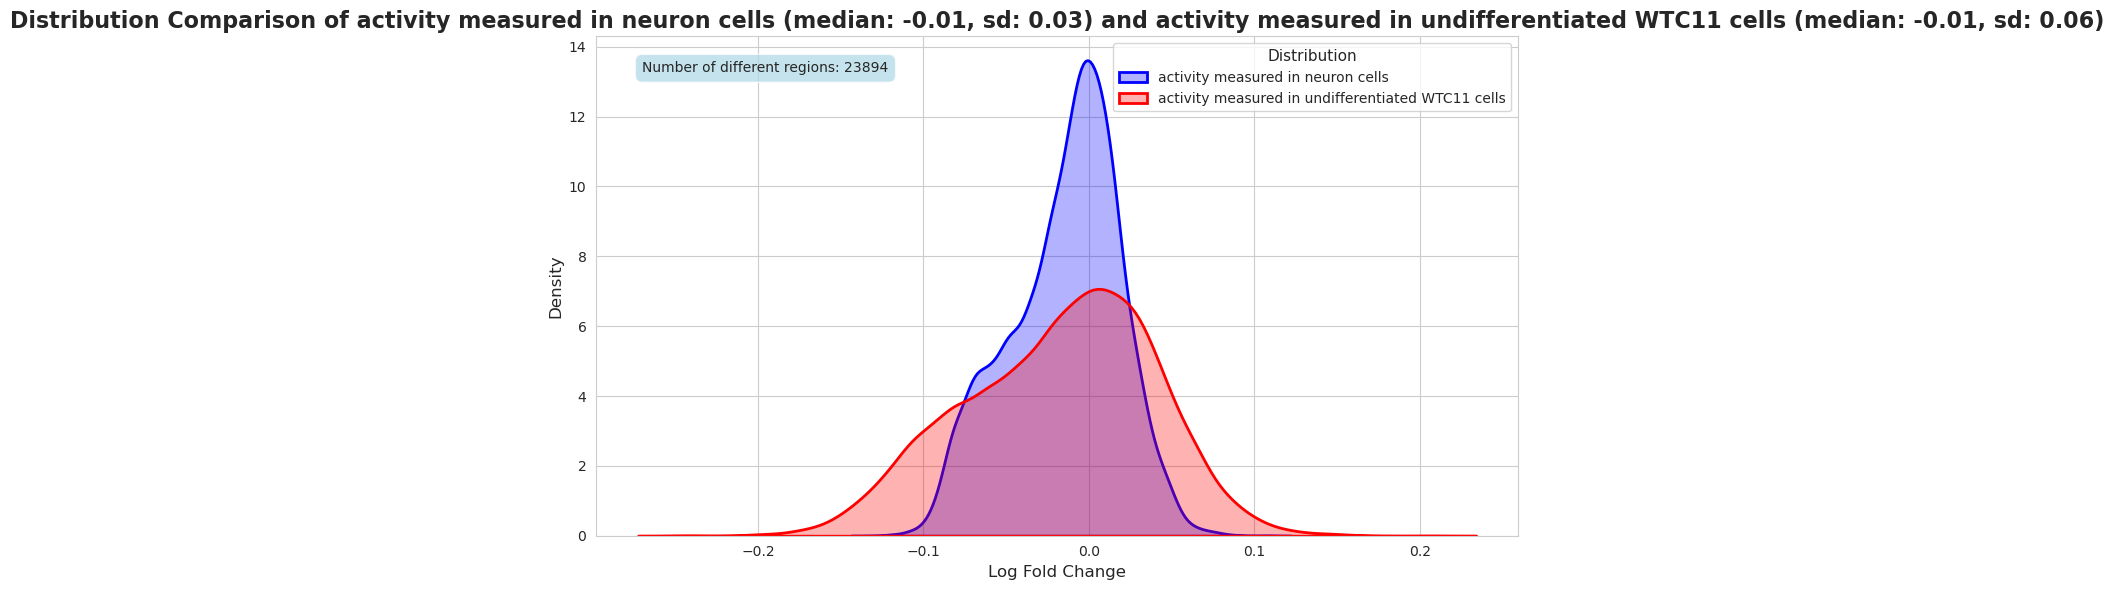

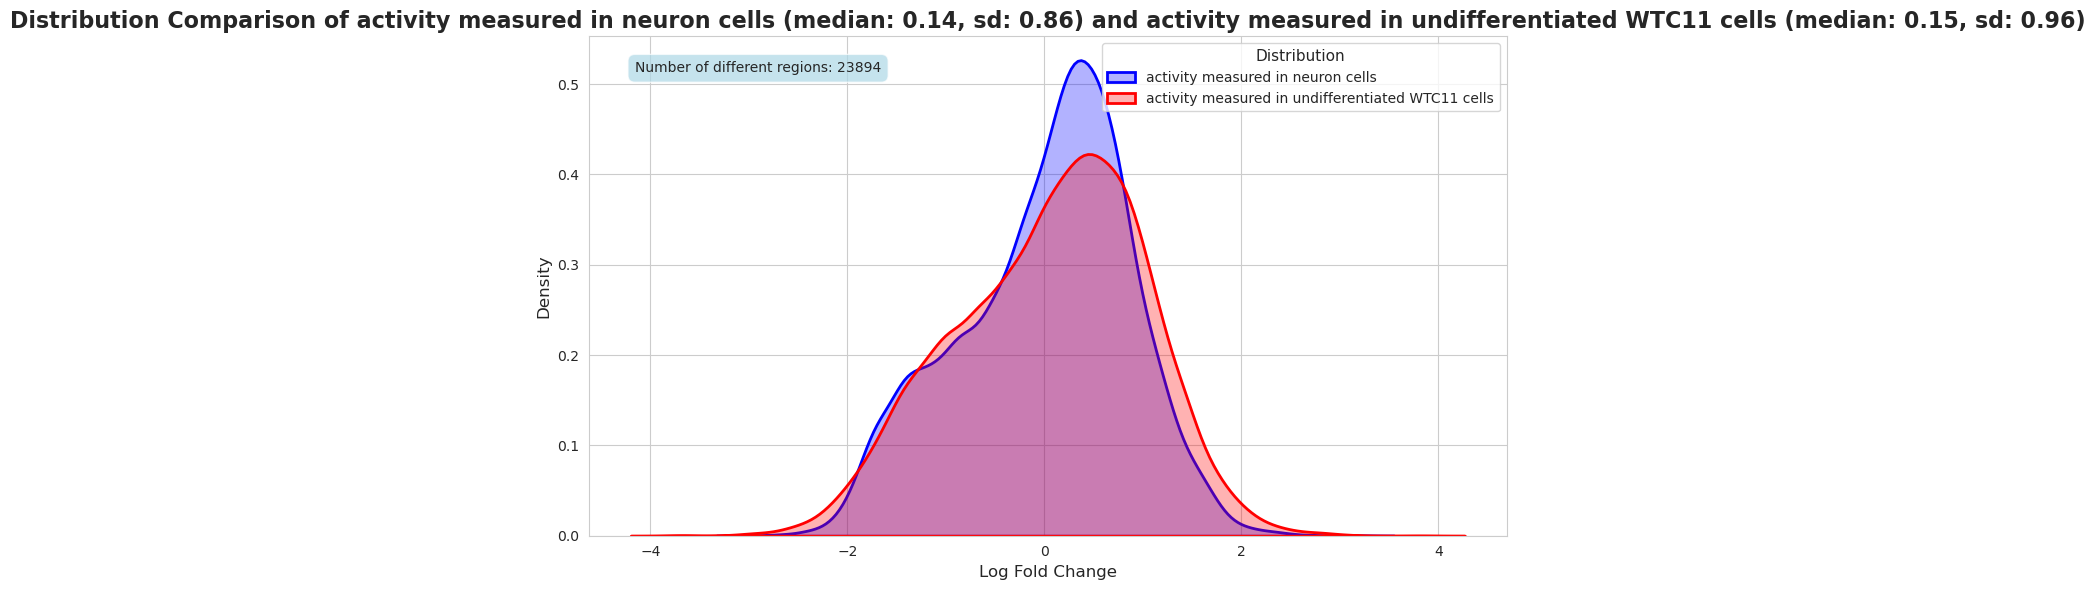

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution_comparison(df, column_one, column_name_one, column_two, column_name_two):
    """Plot the distribution comparison of two columns in a DataFrame."""


    # Calculate Statistics
    # Calculate the median and standard deviation for each column.
    median_first = df[f'{column_one}'].median()
    std_first = df[f'{column_one}'].std()

    median_second = df[f'{column_two}'].median()
    std_second = df[f'{column_two}'].std()

    # Set Up Plot for Publication Readiness
    plt.figure(figsize=(10, 6)) # Set figure size for better readability
    sns.set_style("whitegrid") # Use a clean seaborn style for aesthetics

    # Plot the Distributions
    # Use seaborn's kdeplot to visualize the distributions.
    # 'fill=True' and 'alpha' add a shaded area for better visual comparison.
    sns.kdeplot(df[f'{column_one}'], color='blue', label=f'{column_name_one}', fill=True, alpha=0.3, linewidth=2)
    sns.kdeplot(df[f'{column_two}'], color='red', label=f'{column_name_two}', fill=True, alpha=0.3, linewidth=2)

    # Add Plot Elements (Title, Labels, Legend)
    plt.title(f'Distribution Comparison of {column_name_one} (median: {median_first:.2f}, sd: {std_first:.2f}) and {column_name_two} (median: {median_second:.2f}, sd: {std_second:.2f})', fontsize=16, fontweight='bold')
    plt.xlabel('Log Fold Change', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(title='Distribution', fontsize=10, title_fontsize='11', loc='upper right')

    # Add Text Annotation for Number of Rows
    plt.text(0.05, 0.95, f'Number of different regions: {len(df)}', transform=plt.gca().transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))

    # Final Touches and Saving
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    # plt.savefig('distribution_comparison_plot.png', dpi=300) # Save the plot as a high-resolution PNG
    plt.show() # Display the plot


plot_distribution_comparison(df_elements_both_cell_types_no_alt_no_effect,
                            'raw_activity_NGN2_log2FC_bcalm',
                            'activity measured in neuron cells',
                            'raw_activity_undiffWTC11_log2FC_bcalm',
                            'activity measured in undifferentiated WTC11 cells')
# normalized activity
plot_distribution_comparison(df_elements_both_cell_types_no_alt_no_effect,
                            'normalized_activity_NGN2',
                            'activity measured in neuron cells',
                            'normalized_activity_undiffWTC11',
                            'activity measured in undifferentiated WTC11 cells')


In [46]:
df_elements_both_cell_types_no_alt.columns

Index(['name', 'chr', 'start', 'end', 'strand', 'sequence', 'label',
       'raw_activity_NGN2_log2FC_bcalm', 'bcalm_adj_p_NGN2',
       'normalized_activity_NGN2', 'bcalm_data_exists_NGN2',
       'raw_activity_undiffWTC11_log2FC_bcalm', 'bcalm_adj_p_undiffWTC11',
       'normalized_activity_undiffWTC11', 'bcalm_data_exists_undiffWTC11',
       'SCREEN_ID', 'is_NPC_SCREEN_cCRE', 'is_WTC11_SCREEN_cCRE',
       'is_H9_SCREEN_cCRE', 'is_H1_SCREEN_cCRE', 'is_dCRE_NGN2',
       'is_dCRE_undiffWTC11', 'bcalm_effect_NGN2', 'bcalm_effect_undiffWTC11',
       'measured_in_both_celltypes', 'region', 'NGN2_increasing',
       'undiffWTC11_increasing', 'NGN2_decreasing', 'undiffWTC11_decreasing',
       'NGN2_no_effect', 'undiffWTC11_no_effect'],
      dtype='object')

In [ ]:
df_elements_both_cell_types_no_alt_no_effect

In [48]:
comparison_scenarios = [
    ('no_effect', 'no_effect', 'No Activity in Both Cell-Types'),
    ('no_effect', 'increasing', 'No Activity NGN2 vs Increasing undiffWTC11'),
    ('no_effect', 'decreasing', 'No Activity NGN2 vs Decreasing undiffWTC11'),
    ('increasing', 'no_effect', 'Increasing NGN2 vs No Activity undiffWTC11'),
    ('increasing', 'increasing', 'Increasing NGN2 vs Increasing undiffWTC11'),
    ('increasing', 'decreasing', 'Increasing NGN2 vs Decreasing undiffWTC11'),
    ('decreasing', 'no_effect', 'Decreasing NGN2 vs No Activity undiffWTC11'),
    ('decreasing', 'increasing', 'Decreasing NGN2 vs Increasing undiffWTC11'),
    ('decreasing', 'decreasing', 'Decreasing NGN2 vs Decreasing undiffWTC11'),
]

In [47]:
# --- Set up variables for plotting columns ---
# These are the actual columns containing the numerical data you want to plot
COLUMN_TO_PLOT_1 = "normalized_activity_NGN2"
COLUMN_TO_PLOT_2 = "normalized_activity_undiffWTC11"

# These are the custom labels you want to see in the legend
LEGEND_LABEL_1 = "NGN2 Activity"
LEGEND_LABEL_2 = "undiffWTC11 Activity"

Starting combined plot generation...
Generating plot for: No Activity in Both Cell-Types


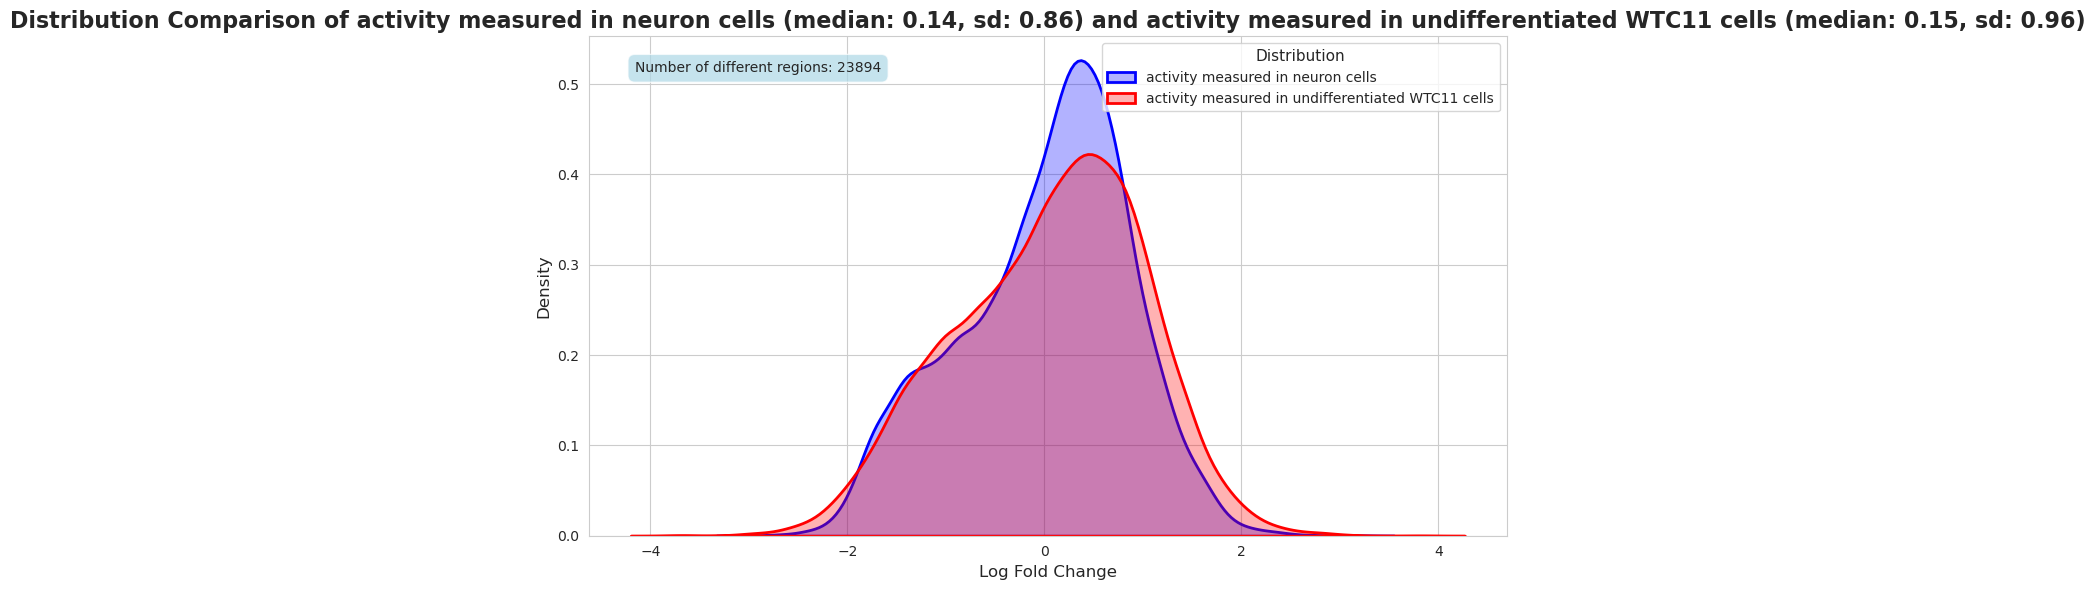

Generating plot for: No Activity NGN2 vs Increasing undiffWTC11


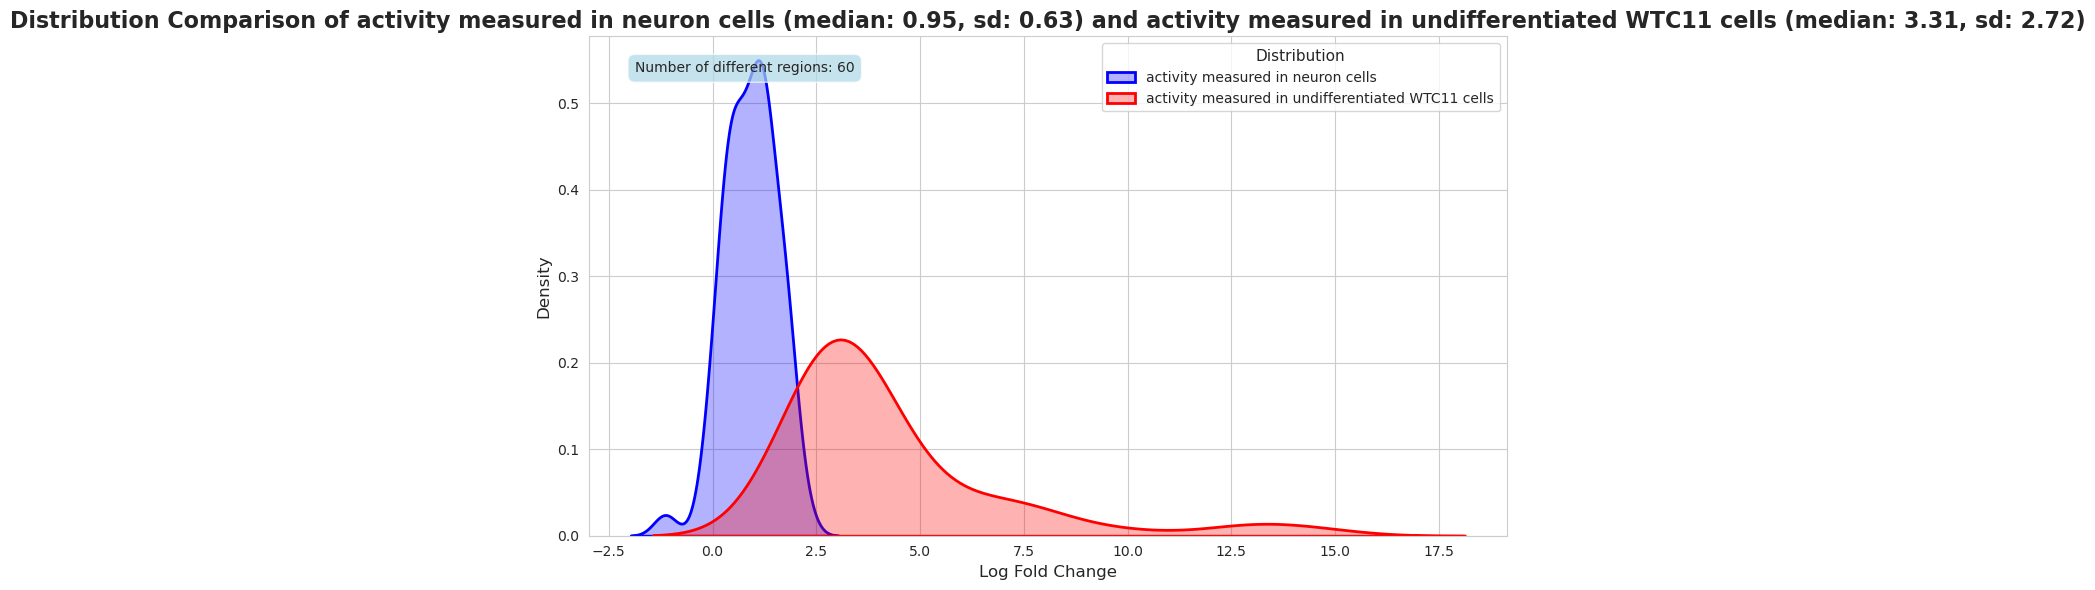

Generating plot for: No Activity NGN2 vs Decreasing undiffWTC11


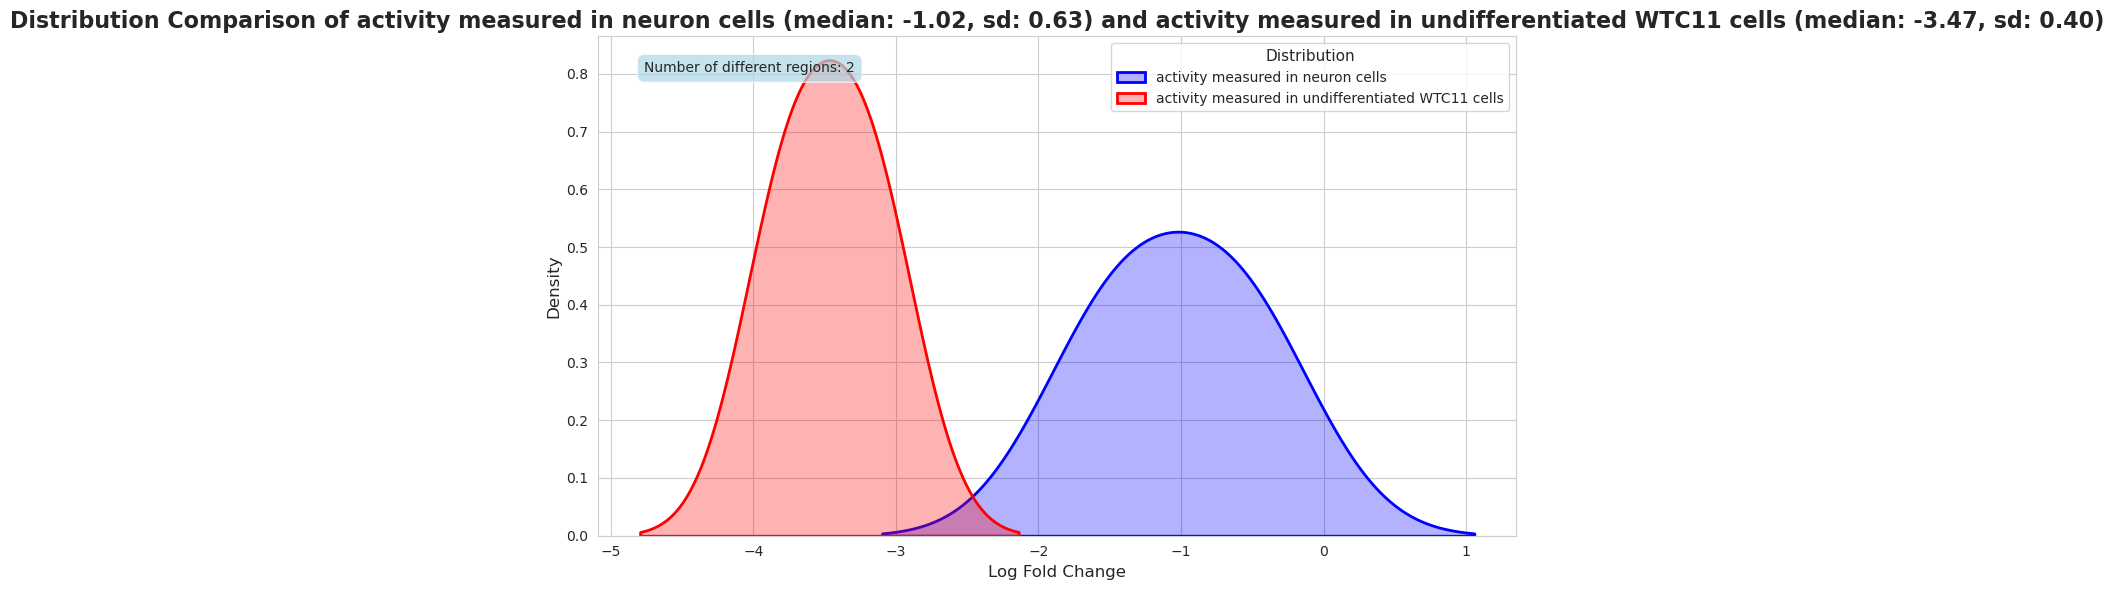

Generating plot for: Increasing NGN2 vs No Activity undiffWTC11


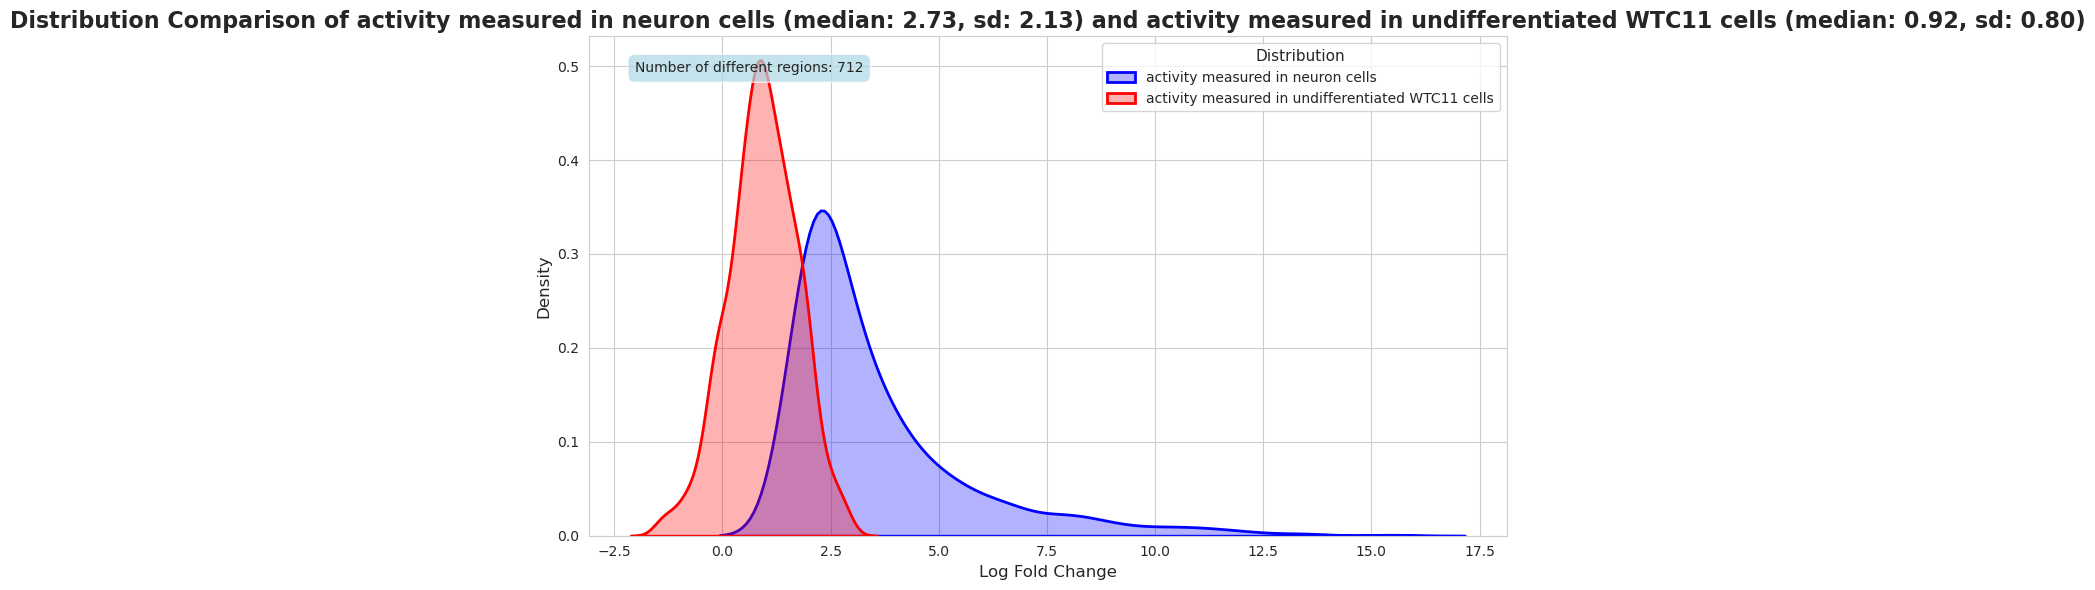

Generating plot for: Increasing NGN2 vs Increasing undiffWTC11


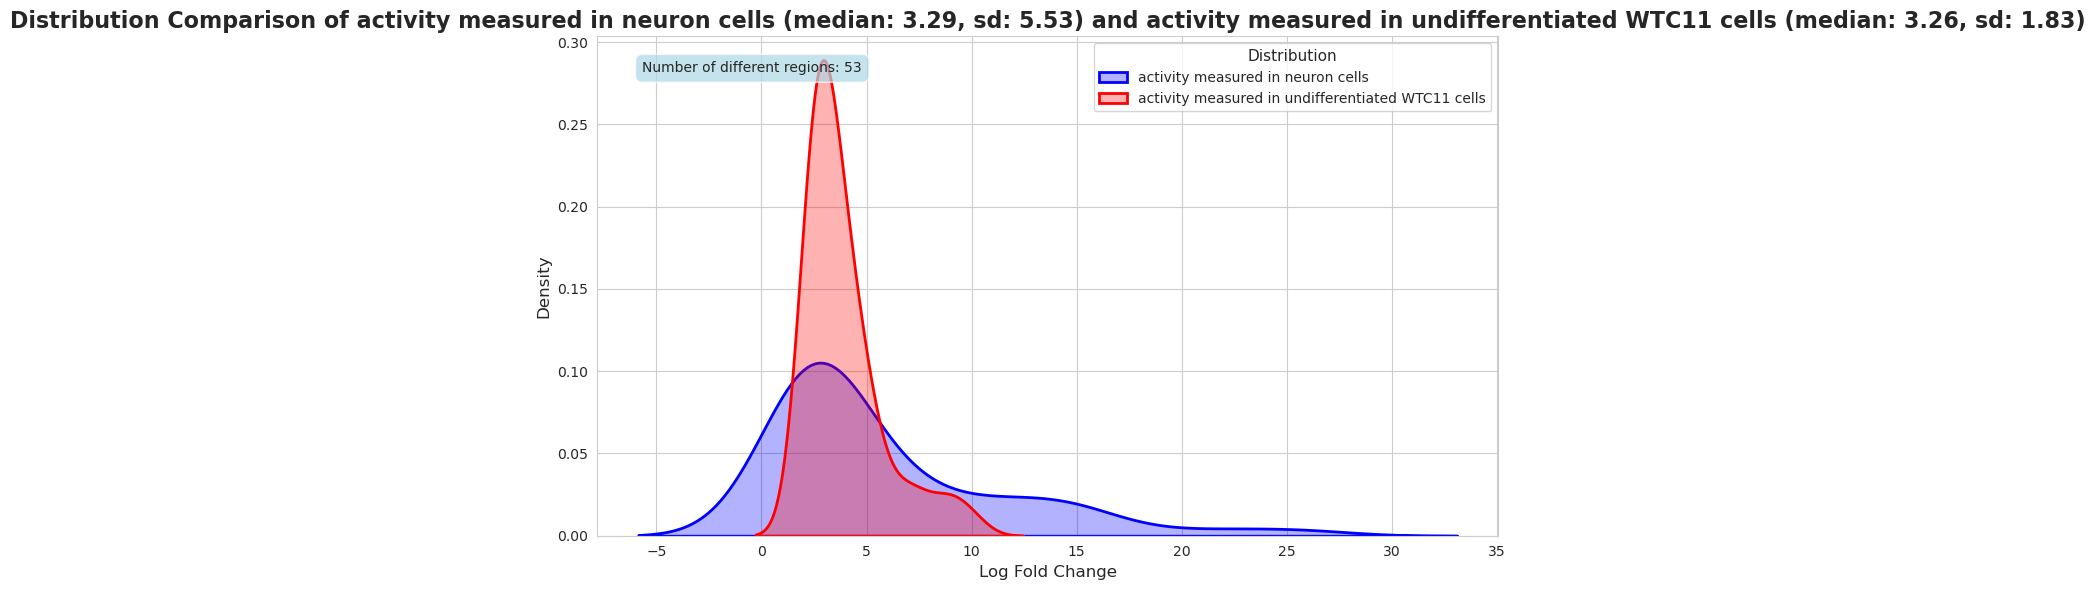

No data for 'Increasing NGN2 vs Decreasing undiffWTC11'. Skipping plot.
Generating plot for: Decreasing NGN2 vs No Activity undiffWTC11


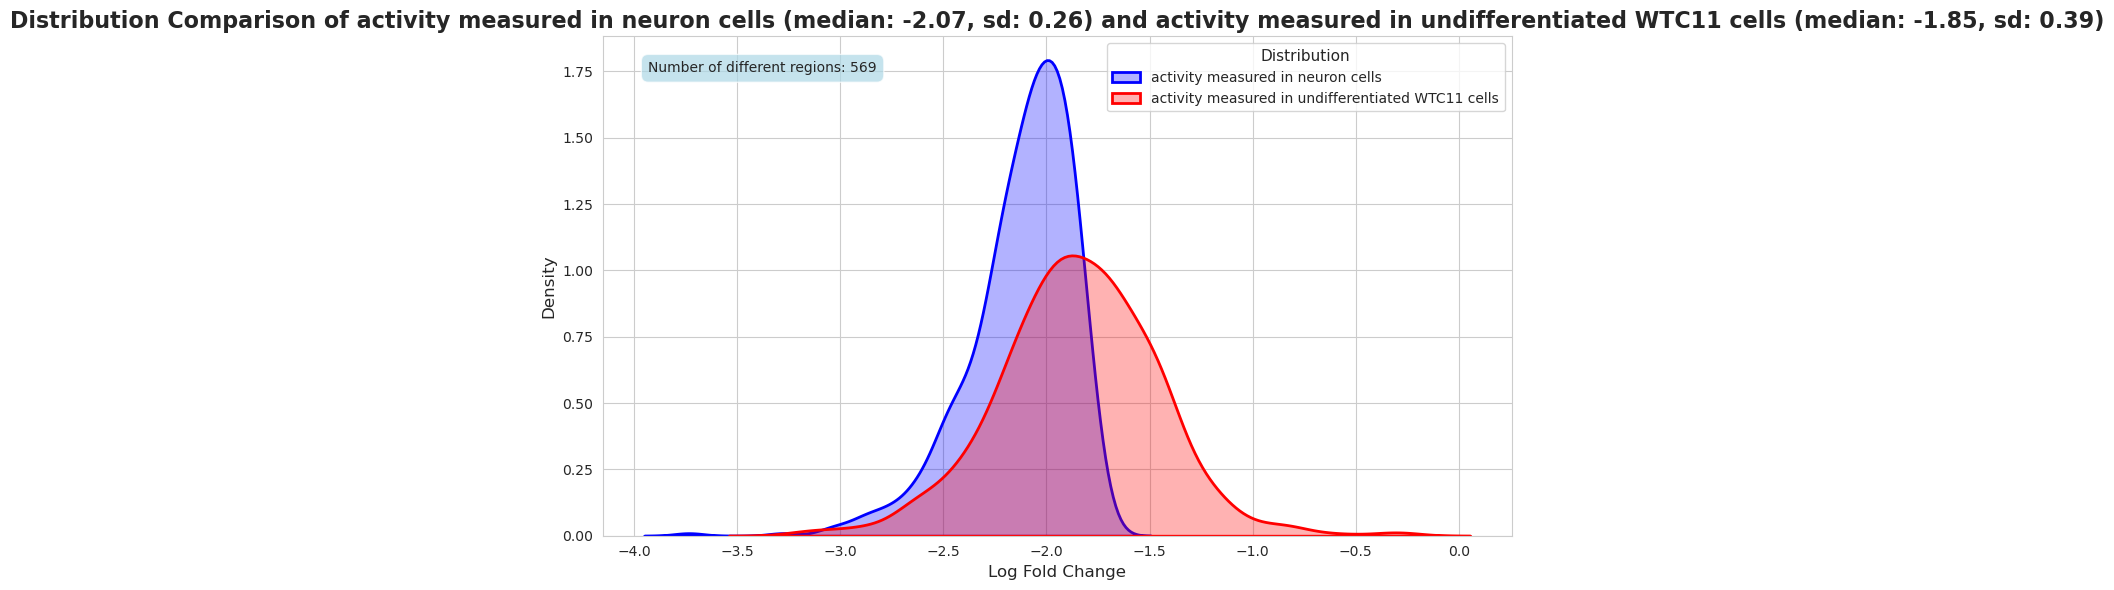

No data for 'Decreasing NGN2 vs Increasing undiffWTC11'. Skipping plot.
Generating plot for: Decreasing NGN2 vs Decreasing undiffWTC11


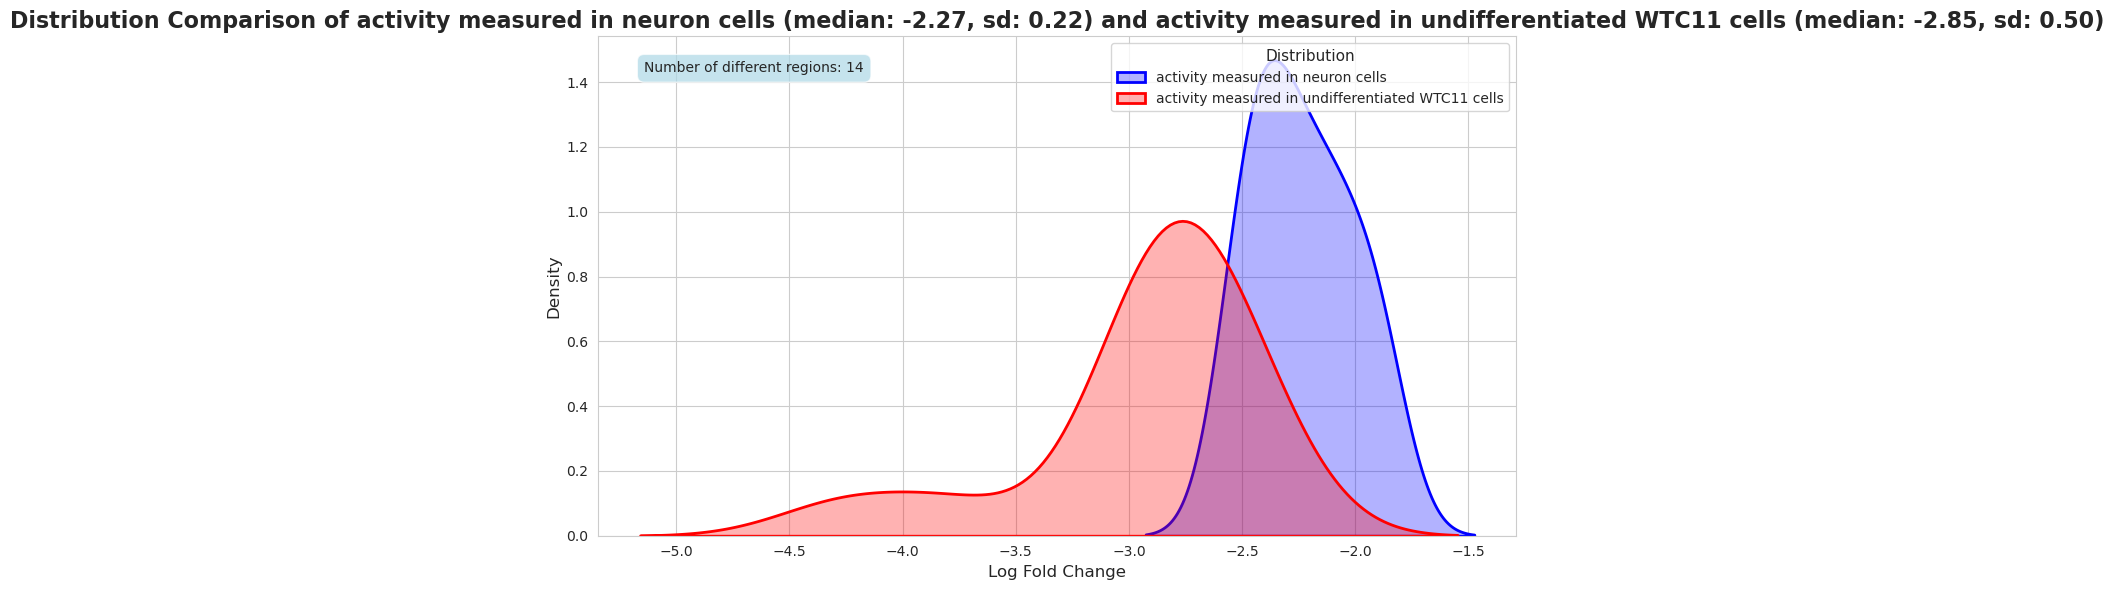

All combined plots generated and saved in the 'comparison_plots_combined' directory.


In [50]:
# --- Iteration Logic to Filter and Plot for Combined Groups ---
print("Starting combined plot generation...")
for ngn2_suffix, undiff_suffix, plot_description in comparison_scenarios:
    # Construct the full boolean column names for filtering
    ngn2_filter_col = f"NGN2_{ngn2_suffix}"
    undiff_filter_col = f"undiffWTC11_{undiff_suffix}"

    # Check if filter columns exist
    if ngn2_filter_col not in df_elements_both_cell_types_no_alt.columns or undiff_filter_col not in df_elements_both_cell_types_no_alt.columns:
        print(f"Warning: One or both filter columns for '{plot_description}' not found. Skipping.")
        continue

    # Apply the combined filter: both conditions must be True
    filtered_df_elements_both_cell_types_no_alt_filtered = df_elements_both_cell_types_no_alt[(df_elements_both_cell_types_no_alt[ngn2_filter_col] == True) & (df_elements_both_cell_types_no_alt[undiff_filter_col] == True)]

    # Check if the filtered DataFrame is empty
    if filtered_df_elements_both_cell_types_no_alt_filtered.empty:
        print(f"No data for '{plot_description}'. Skipping plot.")
        continue

    # Call the plotting function with the filtered data and appropriate labels/title
    print(f"Generating plot for: {plot_description}")
    # plot_distribution_comparison(filtered_df_elements_both_cell_types_no_alt_filtered,
    #                             'raw_activity_NGN2_log2FC_bcalm',
    #                             'activity measured in neuron cells',
    #                             'raw_activity_undiffWTC11_log2FC_bcalm',
    #                             'activity measured in undifferentiated WTC11 cells')
    # normalized activity
    plot_distribution_comparison(filtered_df_elements_both_cell_types_no_alt_filtered,
                                'normalized_activity_NGN2',
                                'activity measured in neuron cells',
                                'normalized_activity_undiffWTC11',
                                'activity measured in undifferentiated WTC11 cells')

print("All combined plots generated and saved in the 'comparison_plots_combined' directory.")

### Next: Gruppen unterschiede anhand der Sequenzen:  o
- 	Welche sequenzbedingten Unterschiede gibt es zwischen den zell-typ spezifischen sequenzen mit signifikanter Aktivität und einer gemeinsamen gruppe von sequenzen, die keine aktivität zeigt?